In [28]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import gget
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.stats import median_abs_deviation
from scipy.stats import pearsonr


sc.settings.verbosity = 2
sc.logging.print_header()

scanpy==1.10.4 anndata==0.11.4 umap==0.5.7 numpy==1.26.4 scipy==1.15.2 pandas==2.2.3 scikit-learn==1.6.1 statsmodels==0.14.4 igraph==0.11.6 pynndescent==0.5.13


# Load in the data

In [29]:
start = time.perf_counter()

path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/raw_merged_gene_data.h5ad"

adata_raw = sc.read_h5ad(path)

sc.logging.print_memory_usage() 
print(f"Total time: {time.perf_counter() - start:.2f} seconds")

print(f"Initial shape: {adata_raw.shape}\n")
print(f"N cells in HYB dataset: {adata_raw[adata_raw.obs['dataset'] == 'Hybrid'].n_obs}")
print(f"N cells in scFib dataset: {adata_raw[adata_raw.obs['dataset'] == 'Control'].n_obs}\n")

adata_raw

Memory usage: current 4.37 GB, difference +3.15 GB
Total time: 1.97 seconds
Initial shape: (19858, 28702)

N cells in HYB dataset: 10895
N cells in scFib dataset: 8963



AnnData object with n_obs × n_vars = 19858 × 28702
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End'

In [30]:
### --- Handle HYB cells with NaN feature barcode predictions ---
init_cells_hybrid = adata_raw[adata_raw.obs['dataset'] == 'Hybrid'].n_obs

# remove HYB cells with NaN feature barcode predictions
hybrid_to_remove = (adata_raw.obs['dataset'] == 'Hybrid') & (adata_raw.obs['assigned_condition'].isna())
cells_to_keep = ~(hybrid_to_remove)
adata_raw = adata_raw[cells_to_keep].copy()

final_cells_hybrid = adata_raw[adata_raw.obs['dataset'] == 'Hybrid'].n_obs
removed_hybrid_cells = init_cells_hybrid - final_cells_hybrid

print(f"Removed {removed_hybrid_cells} 'Hybrid' cells with unassigned feature barcodes")
print(f"Final shape: {adata_raw.shape}")


### --- Add new column for grouping HYB cells vs Controls ---
adata_raw.obs['pooled_condition'] = adata_raw.obs['assigned_condition'].replace({
    "G1": "Control",
    "S": "Control",
    "G2M": "Control",
    "PRRX1": "siPRRX1",
    "PRRX1_MYOD": "siPRRX1/mmMYOD1",
    "MYOD": "mmMYOD1"
})

# fill remaining NaN feature barcode predictions (only control cells) with 'Control'
adata_raw.obs['pooled_condition'] = adata_raw.obs['pooled_condition'].fillna('Control')
print(adata_raw.obs['pooled_condition'].value_counts())

adata_raw

Removed 1 'Hybrid' cells with unassigned feature barcodes
Final shape: (19857, 28702)
pooled_condition
Control            8963
siPRRX1/mmMYOD1    4174
siPRRX1            3955
mmMYOD1            2765
Name: count, dtype: int64


/tmp/ipykernel_1148205/1807916870.py:17: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_raw.obs['pooled_condition'] = adata_raw.obs['assigned_condition'].replace({


AnnData object with n_obs × n_vars = 19857 × 28702
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End'

# QC (combined)

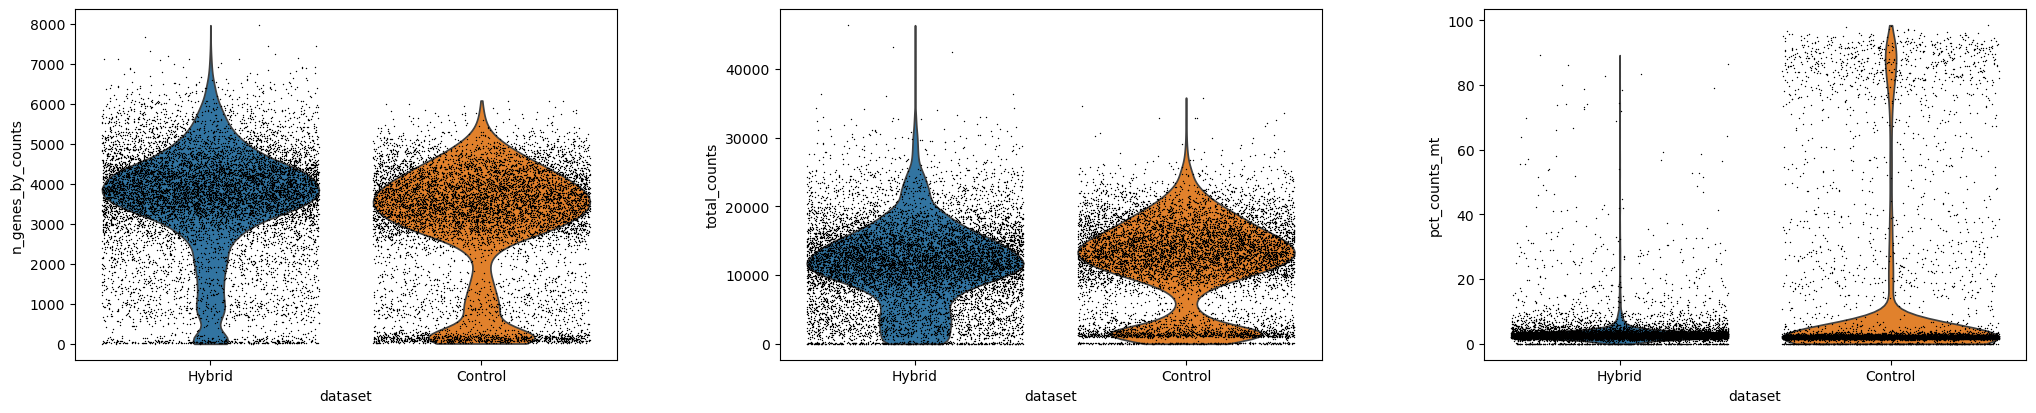

In [31]:
adata = adata_raw.copy()

# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], inplace=True, log1p=True)

plt.rcdefaults()
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    groupby='dataset',
)

## Cell filtering (MADs)

In [32]:
# Identify outlier cells with MADs per dataset
def is_outlier_by_group(adata, metric: str, nmads: int, group_col: str = 'dataset'):
    outlier_series = pd.Series(False, index=adata.obs.index)
    unique_groups = adata.obs[group_col].unique()

    for group in unique_groups:
        group_mask = (adata.obs[group_col] == group)
        M_group = adata.obs.loc[group_mask, metric]

        if len(M_group) < 2 or M_group.isnull().all():
            continue

        median_val_group = np.median(M_group)
        mad_val_group = median_abs_deviation(M_group)

        if mad_val_group == 0:
            continue

        outliers_in_group = (M_group < median_val_group - nmads * mad_val_group) | \
                            (median_val_group + nmads * mad_val_group < M_group)

        outlier_series.loc[group_mask] = outliers_in_group

    return outlier_series


adata.obs["outlier"] = (
    is_outlier_by_group(adata, "log1p_total_counts", 5, 'dataset')
    | is_outlier_by_group(adata, "log1p_n_genes_by_counts", 5, 'dataset')
)

print("Number of outlier cells per dataset based on counts:")
print(adata.obs.groupby('dataset', observed=True)['outlier'].sum())


adata.obs["mt_outlier"] = is_outlier_by_group(adata, "pct_counts_mt", 5, 'dataset') | (
    adata.obs["pct_counts_mt"] > 20
)

print("\nNumber of outlier cells per dataset based on pct mito:")
adata.obs.groupby('dataset', observed=True)['mt_outlier'].sum()

Number of outlier cells per dataset based on counts:
dataset
Hybrid     1184
Control    1676
Name: outlier, dtype: int64

Number of outlier cells per dataset based on pct mito:


dataset
Hybrid      788
Control    1852
Name: mt_outlier, dtype: int64

In [33]:
init_cells = adata.n_obs
init_cells_hyb = adata[adata.obs['dataset'] == 'Hybrid'].n_obs
init_cells_fib = adata[adata.obs['dataset'] == 'Control'].n_obs

print(f"Total number of cells: {init_cells}")
print(f"N cells in Hybird: {init_cells_hyb}")
print(f"N cells in Control: {init_cells_fib}")

print(f"\nFiltering...")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

final_cells = adata.n_obs
final_cells_hyb = adata[adata.obs['dataset'] == 'Hybrid'].n_obs
final_cells_fib = adata[adata.obs['dataset'] == 'Control'].n_obs


print(f"\nRemoved {init_cells - final_cells} total cells.")
print(f"Removed {init_cells_hyb - final_cells_hyb} from Hybrid dataset.")
print(f"Removed {init_cells_fib - final_cells_fib} from Control dataset.")


print(f"\nTotal cells after filtering of low quality cells: {final_cells}")
print(f"N cells in Hybird: {final_cells_hyb}")
print(f"N cells in Control: {final_cells_fib}")

Total number of cells: 19857
N cells in Hybird: 10894
N cells in Control: 8963

Filtering...

Removed 3490 total cells.
Removed 1487 from Hybrid dataset.
Removed 2003 from Control dataset.

Total cells after filtering of low quality cells: 16367
N cells in Hybird: 9407
N cells in Control: 6960


## Gene filtering and normalization

In [34]:
# keep full dimension safe
adata.raw = adata  

# save raw counts
adata.layers['raw_counts'] = adata.X.copy()

print("Filtering...\n")

sc.pp.filter_genes(adata, min_counts=10)


print("\nNormalizing counts...\n")
sc.pp.normalize_total(
    adata,
    target_sum=1e4,
)

# save normalized counts
adata.layers['norm_counts'] = adata.X.copy()

# log transform normalized counts
sc.pp.log1p(adata)

# save log normalized counts
adata.layers['log_norm'] = adata.X.copy()


print(f"{adata.obs['dataset'].value_counts()}\n")
print(f"{adata.obs['pooled_condition'].value_counts()}\n")

Filtering...

filtered out 3576 genes that are detected in less than 10 counts

Normalizing counts...

normalizing counts per cell
    finished (0:00:00)
dataset
Hybrid     9407
Control    6960
Name: count, dtype: int64

pooled_condition
Control            6960
siPRRX1            3689
siPRRX1/mmMYOD1    3462
mmMYOD1            2256
Name: count, dtype: int64



# HVGs

extracting highly variable genes
    finished (0:00:05)
Number of HVG: 2000


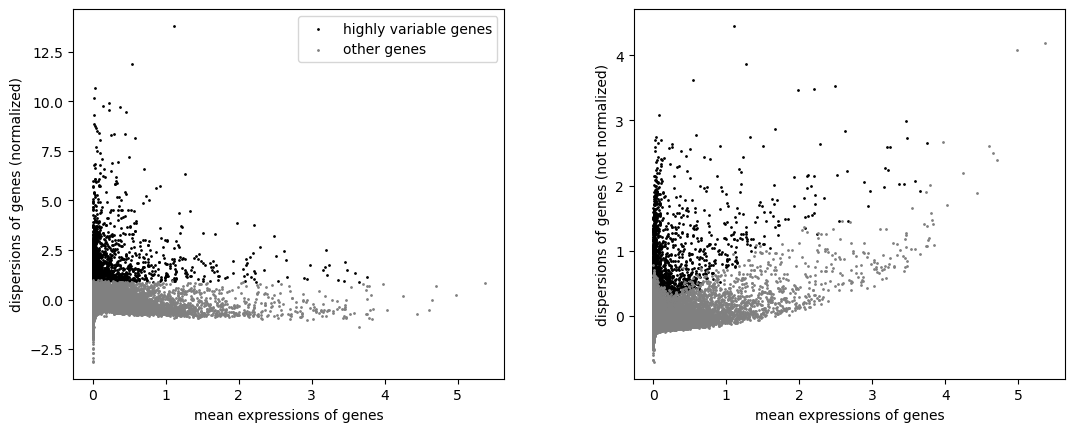

In [35]:
adata.X = adata.layers['log_norm']

sc.pp.highly_variable_genes(
    adata,
    batch_key='dataset',
    n_top_genes=2000, 
)

print(f"Number of HVG: {adata.var['highly_variable'].sum()}")

plt.rcdefaults()
sc.pl.highly_variable_genes(adata)

# PCA

computing PCA
    with n_comps=50
    finished (0:00:03)


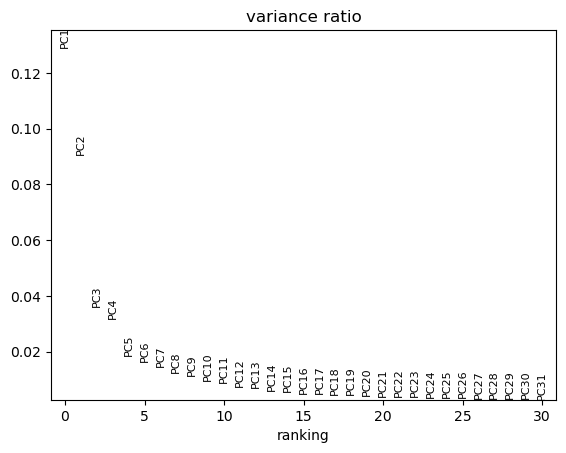

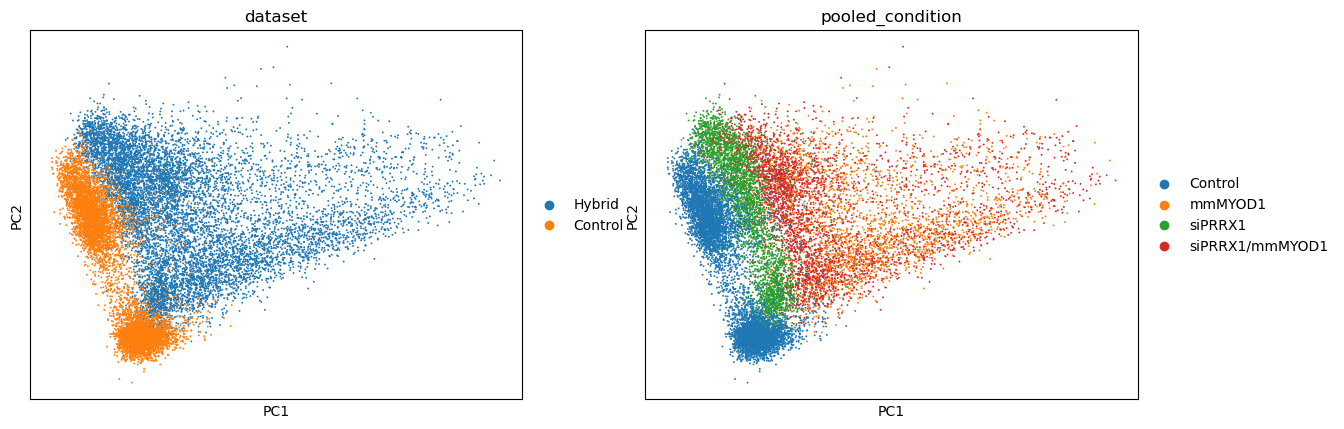

AnnData object with n_obs × n_vars = 16367 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'da

In [36]:
sc.pp.pca(adata)

sc.pl.pca_variance_ratio(adata)
sc.pl.pca(adata, color=['dataset', 'pooled_condition'])

adata

# Harmony integration

2025-06-30 14:25:04,094 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
Mon Jun 30 14:25:04 2025 INFO Computing initial centroids with sklearn.KMeans...
2025-06-30 14:25:07,132 - harmonypy - INFO - sklearn.KMeans initialization complete.
Mon Jun 30 14:25:07 2025 INFO sklearn.KMeans initialization complete.
2025-06-30 14:25:07,214 - harmonypy - INFO - Iteration 1 of 10
Mon Jun 30 14:25:07 2025 INFO Iteration 1 of 10
2025-06-30 14:25:11,242 - harmonypy - INFO - Iteration 2 of 10
Mon Jun 30 14:25:11 2025 INFO Iteration 2 of 10
2025-06-30 14:25:15,193 - harmonypy - INFO - Converged after 2 iterations
Mon Jun 30 14:25:15 2025 INFO Converged after 2 iterations


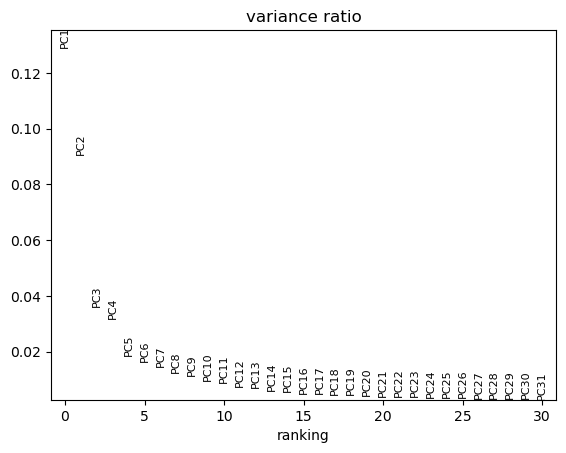

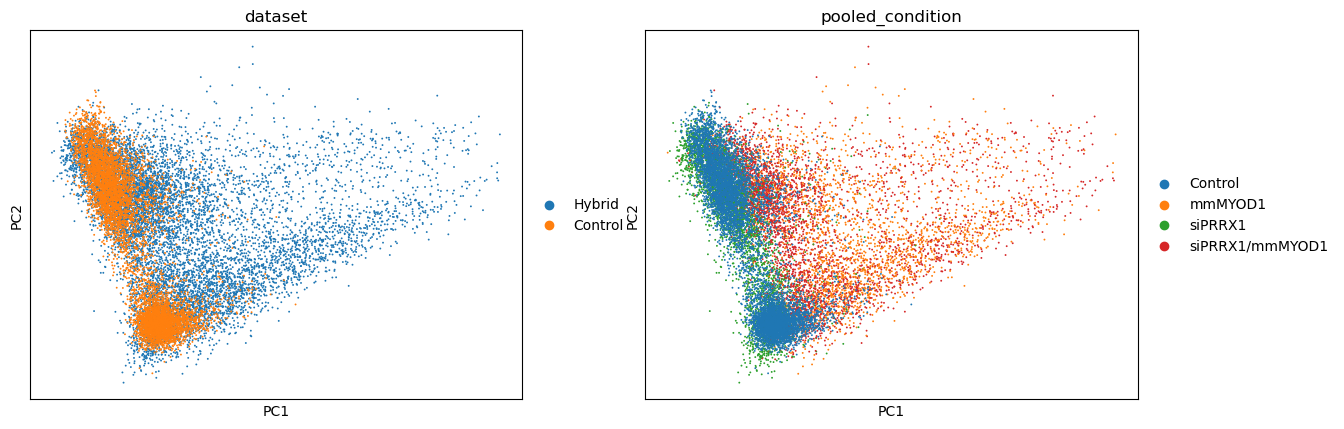

In [37]:
sce.pp.harmony_integrate(adata, 'dataset')

# Save original PCA space
adata.obsm["X_pca_original"] = adata.obsm["X_pca"].copy()

# Set Harmony-corrected PCA as the default for plotting and MAGIC imputation
adata.obsm["X_pca"] = adata.obsm["X_pca_harmony"].copy()

sc.pl.pca_variance_ratio(adata)
sc.pl.pca(adata, color=['dataset', 'pooled_condition'])

N cells per dataset post-filtering:


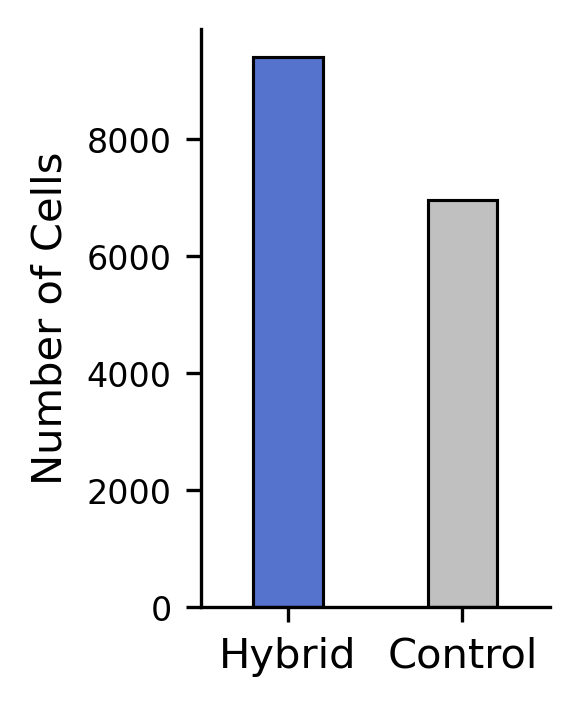

In [38]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 1.5, 2.5
fig, axs = plt.subplots()

dataset_colors = ["royalblue", "silver"]

print("N cells per dataset post-filtering:")

sns.countplot(data=adata.obs,
            x='dataset',
            hue='dataset',
            width=0.4,
            ec='k',
            linewidth=0.75,
            palette=dataset_colors,
           )

plt.ylabel("Number of Cells")
plt.xlabel("")

plt.yticks(fontsize=8)

sns.despine()
plt.show()

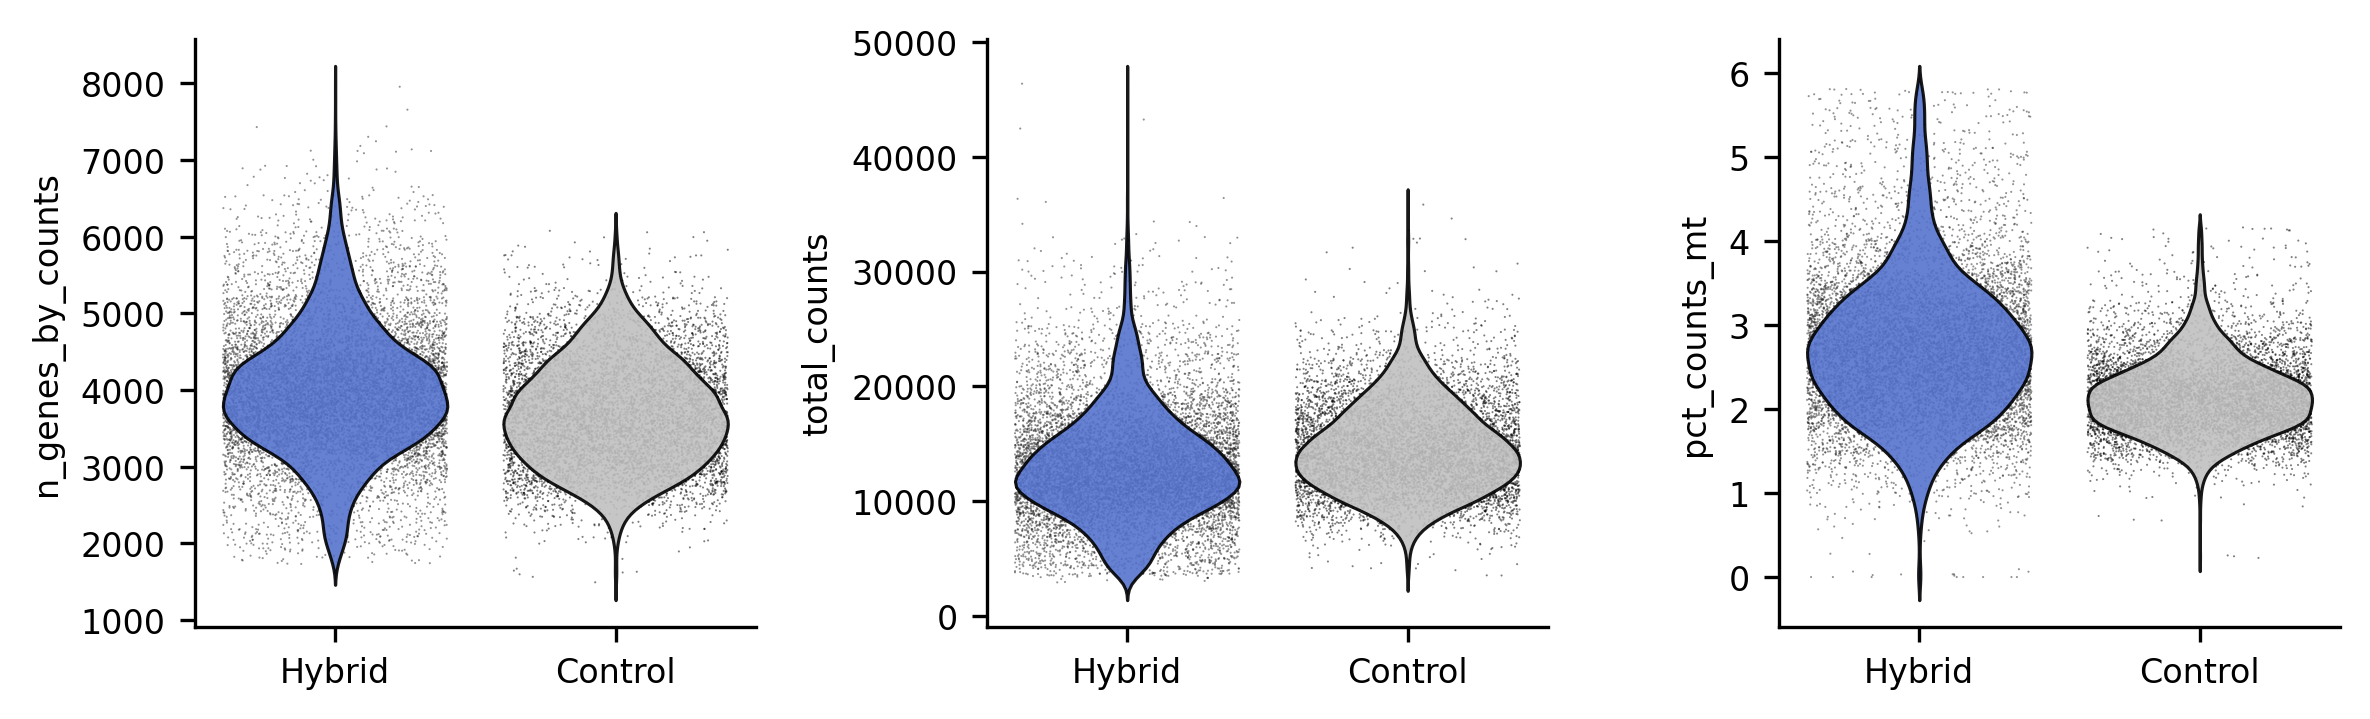

In [39]:
metrics = ['n_genes_by_counts', 'total_counts', 'pct_counts_mt']
dataset_colors = ["royalblue", "silver"]

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (8, 2.5)  # Wider figure for 3 subplots

fig, axs = plt.subplots(1, 3, sharey=False)

for ax, metric in zip(axs, metrics):
    sns.violinplot(
        data=adata.obs,
        x='dataset',
        y=metric,
        hue='dataset',
        linewidth=0.75,
        linecolor='k',
        palette=dataset_colors,
        inner=None,
        alpha=0.9,
        zorder=1,
        ax=ax,
        legend=False,
    )

    sns.stripplot(
        data=adata.obs,
        x='dataset',
        y=metric,
        hue='dataset',
        jitter=0.4,
        palette='dark:black',
        edgecolor=None,
        size=0.5,
        alpha=0.5,
        ax=ax,
        legend=False,
        zorder=0,
    )

    ax.set_xlabel("")
    ax.set_ylabel(metric, fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

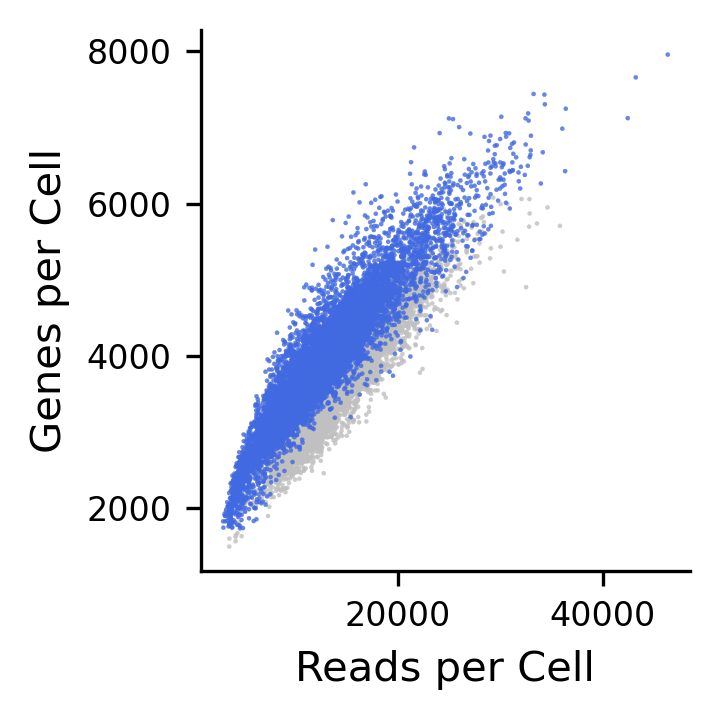

In [40]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 2.5, 2.5

df = adata.obs[['total_counts', 'n_genes_by_counts', 'dataset']].copy()
df = df.sort_values(by='dataset', ascending=False)

colors = ["silver", "royalblue"]

sns.scatterplot(data=df,
                x='total_counts',
                y='n_genes_by_counts',
                hue='dataset',
                hue_order=['Control', 'Hybrid'],
                s=1,
                edgecolor=None,
                alpha=0.8,
                palette=colors,
                legend=False
               )

# sns.move_legend(plt.gca(), loc='lower right', fontsize='small', markerscale=3, title="")#, bbox_to_anchor=(1.1, 1))

plt.ylabel("Genes per Cell")
plt.xlabel("")
plt.xlabel("Reads per Cell")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

sns.despine()
plt.tight_layout()
plt.show()

In [41]:
corr, pval = pearsonr(adata.obs['total_counts'], adata.obs['n_genes_by_counts'])

print(f"\nPearson Correlation (total_counts vs. n_genes_by_counts): {corr:.4f}")
print(f"P-value: {pval:.4e}")


corr, pval = pearsonr(adata.obs['total_counts'], adata.obs['pct_counts_mt'])

print(f"\nPearson Correlation (total_counts vs. pct_counts_mt): {corr:.4f}")
print(f"P-value: {pval:.4e}\n")


corr_df = adata.obs[['dataset', 'total_counts', 'n_genes_by_counts']].copy()

corr_by_dataset = corr_df.groupby('dataset', observed=True).corr()
corr_by_dataset


Pearson Correlation (total_counts vs. n_genes_by_counts): 0.8652
P-value: 0.0000e+00

Pearson Correlation (total_counts vs. pct_counts_mt): -0.3357
P-value: 0.0000e+00



total_counts  n_genes_by_counts
dataset                                                   
Hybrid  total_counts           1.000000           0.924146
        n_genes_by_counts      0.924146           1.000000
Control total_counts           1.000000           0.919580
        n_genes_by_counts      0.919580           1.000000

In [42]:
# sc.pp.neighbors(
#     adata,
#     use_rep='X_pca_harmony',
#     n_neighbors=10,
# )

# sc.tl.tsne(
#     adata,
#     use_rep='X_pca_harmony',

# )

# sc.tl.leiden(
#     adata,
#     resolution=0.5,
#     flavor="igraph",
#     n_iterations=-1, 
# )

# adata.obs['cluster_str'] = adata.obs['leiden'].apply(lambda x: f"C{str(int(x) + 1)}")

# sc.pl.tsne(
#     adata,
#     color=['dataset', 'pooled_condition', 'log1p_n_genes_by_counts', 'cluster_str'],
#     ncols=2,
#     add_outline=True,
#     outline_color=('k', 'k'),
#     frameon=False,
#     alpha=1,
# )

# UMAP

computing neighbors
    finished (0:00:02)
computing UMAP
    finished (0:00:12)
running Leiden clustering
    finished (0:00:00)


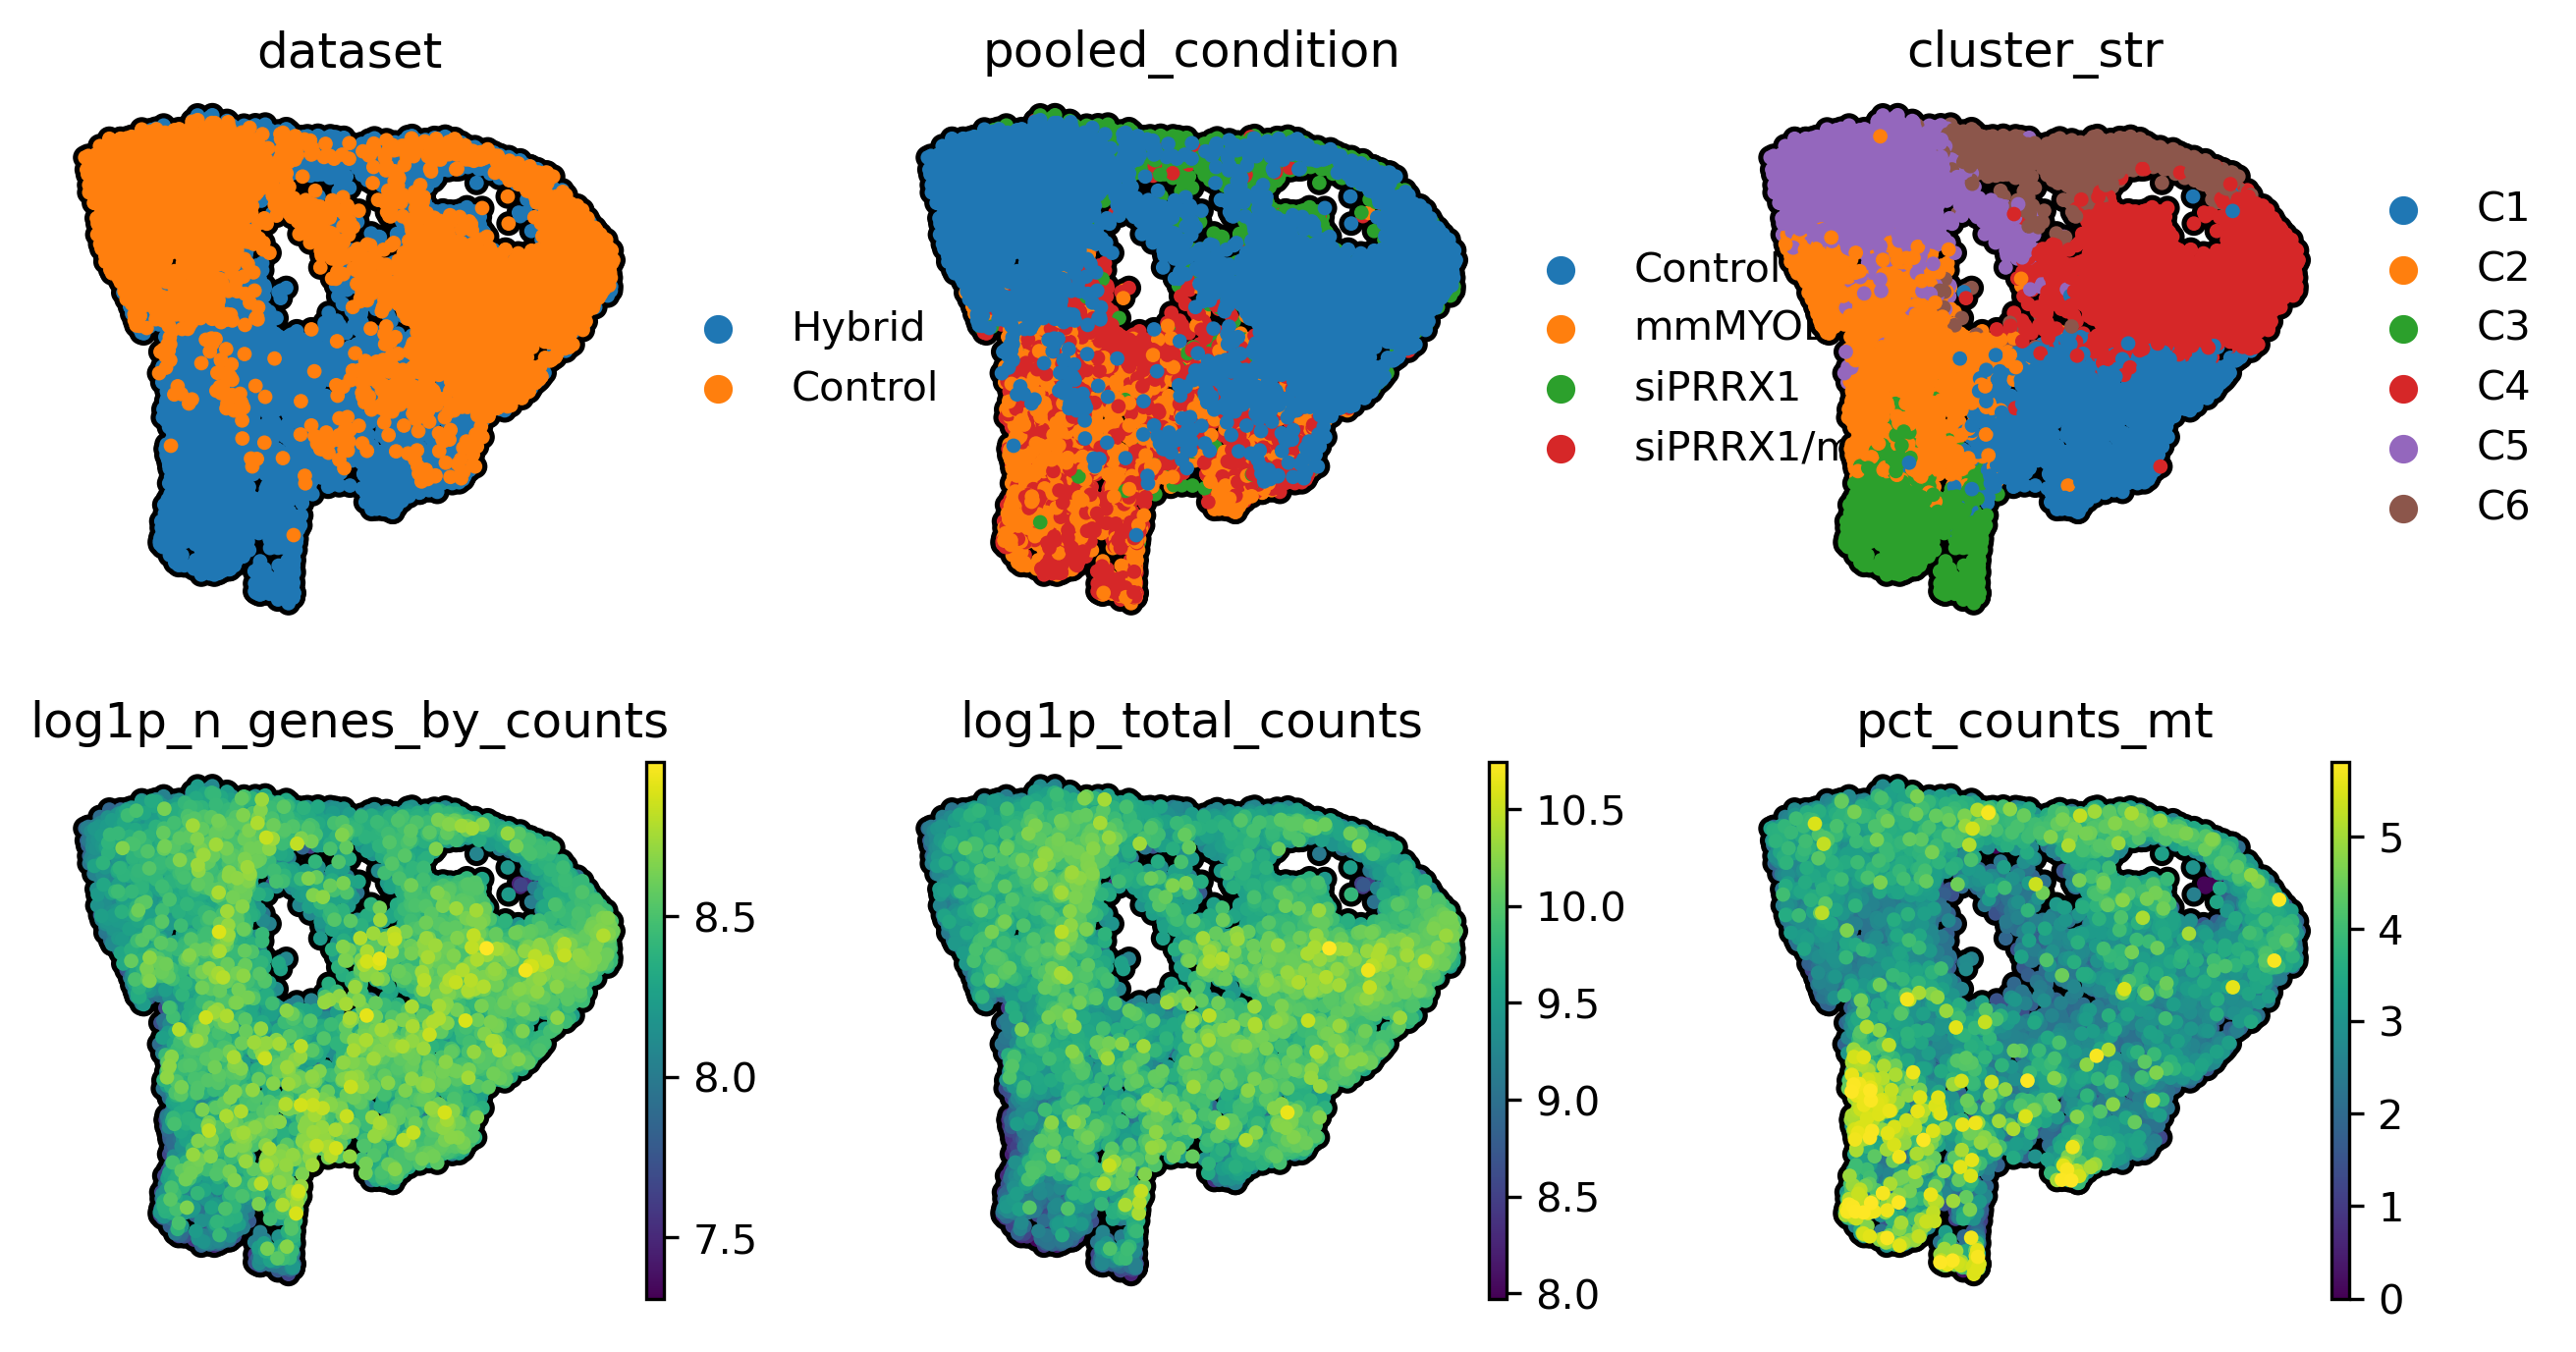

In [43]:
sc.pp.neighbors(
    adata,
    use_rep='X_pca_harmony',
    n_neighbors=10,
)

sc.tl.umap(
    adata,
    min_dist=0.2
)

sc.tl.leiden(
    adata,
    resolution=0.4,
    flavor="igraph",
    n_iterations=-1, 
)

adata.obs['cluster_str'] = adata.obs['leiden'].apply(lambda x: f"C{str(int(x) + 1)}")

sc.pl.umap(
    adata,
    color=['dataset', 'pooled_condition', 'cluster_str', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_mt'],
    ncols=3,
    size=50,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

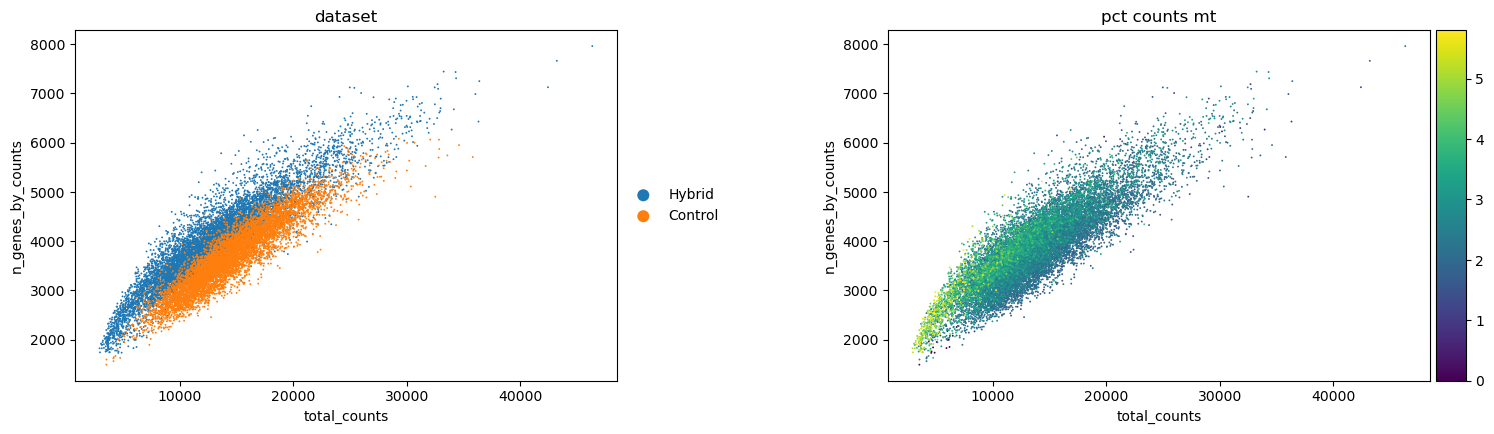

In [44]:
plt.rcdefaults()
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color=["dataset", "pct_counts_mt"])

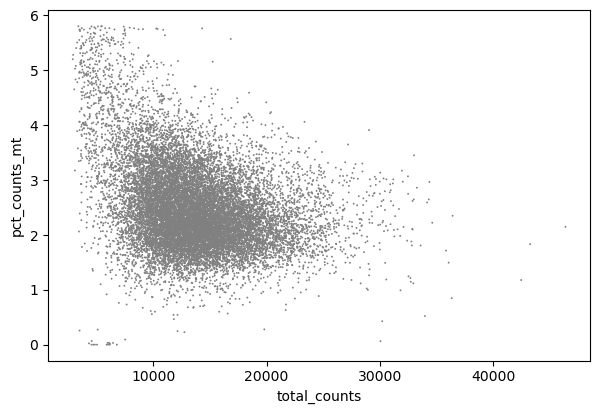

In [45]:
sc.pl.scatter(adata, 'total_counts', 'pct_counts_mt')

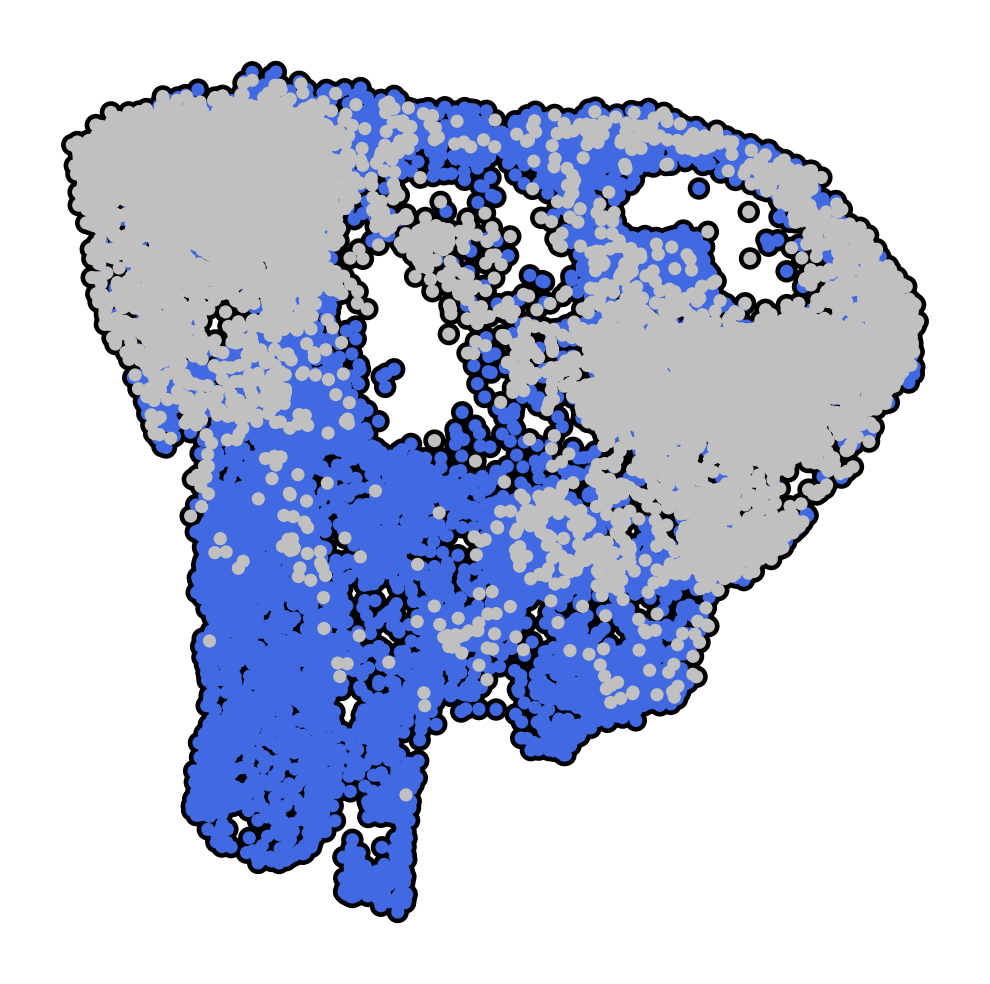

In [46]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

dataset_colors = ["royalblue", "silver"]

sc.pl.umap(
    adata,
    color='dataset',
    size=40,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False, 
    alpha=1,
    title="",
    palette=dataset_colors,
    legend_loc='none',
)

In [47]:
adata

AnnData object with n_obs × n_vars = 16367 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden', 'cluster_str'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_i

# Score cell cycle genes

S phase genes: 43
G2M phase genes: 54
calculating cell cycle phase
computing score 'S_score'
    finished (0:00:01)
computing score 'G2M_score'
    finished (0:00:01)


... storing 'phase' as categorical


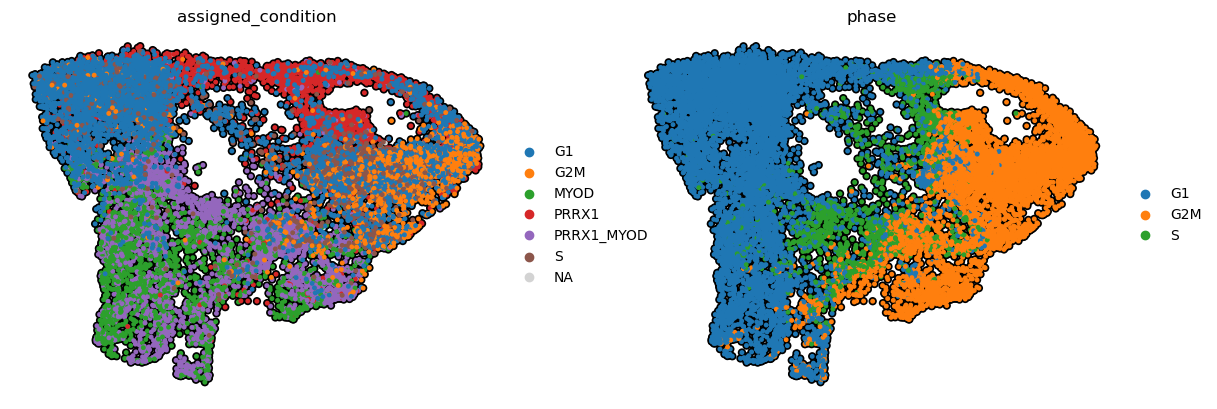

AnnData object with n_obs × n_vars = 16367 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden', 'cluster_str', 'S_score', 'G2M_score', 'phase'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_varia

In [48]:
path = "/nfs/turbo/umms-indikar/Ram/projects/reprogramming/Genexpression/Pseudotime/data/regev_lab_cell_cycle_genes.txt"

cell_cycle_genes = [x.strip() for x in open(path)]

s_genes = cell_cycle_genes[:43]
print(f"S phase genes: {len(s_genes)}")

g2m_genes = cell_cycle_genes[43:]
print(f"G2M phase genes: {len(g2m_genes)}")

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

plt.rcdefaults()

sc.pl.umap(
    adata,
    color=['assigned_condition', 'phase'],
    ncols=2,
    size=50,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

adata

In [46]:
### --- Add filtering metadata to adata.uns ---
adata.uns['processing_parameters'] = {
    # 'max_pct_mito': 20,
    # 'min_counts_per_cell': 500,
    'Cell filtering': 'Low quality (outlier) cells were identified via median absolute deviation (MAD) filtering on log1p_total_counts, log1p_n_genes_by_counts, and pct_counts_mt per dataset. A MAD threshold of 5 was used.',
    'min_counts_per_gene': 10,
    'Normalization': 'Raw counts were normalized to 10,000 per cell and log-transformed.',
    'HVGs': 'Default flavor. 2,000 total HVGs selected with batch_key = dataset.',
    'Integration': 'Datasets integrated using Harmony with default parameters.',
    'UMAP': 'Neighbors selected using Harmony-corrected PCA (n=10). min_dist = 0.2. Leiden resolution = 0.4.',
    'Cell cycle phases': 'Cell cycle phases were predicted using the Regev Lab genes.',
}

adata.uns['processing_parameters']

{'Cell filtering': 'Low quality (outlier) cells were identified via median absolute deviation (MAD) filtering on log1p_total_counts, log1p_n_genes_by_counts, and pct_counts_mt per dataset. A MAD threshold of 5 was used.',
 'min_counts_per_gene': 10,
 'Normalization': 'Raw counts were normalized to 10,000 per cell and log-transformed.',
 'HVGs': 'Default flavor. 2,000 total HVGs selected with batch_key = dataset.',
 'Integration': 'Datasets integrated using Harmony with default parameters.',
 'UMAP': 'Neighbors selected using Harmony-corrected PCA (n=10). min_dist = 0.2. Leiden resolution = 0.4.',
 'Cell cycle phases': 'Cell cycle phases were predicted using the Regev Lab genes.'}

In [47]:
adata.write_h5ad("/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_merged_gene_data.h5ad")
adata

AnnData object with n_obs × n_vars = 16367 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden', 'cluster_str', 'S_score', 'G2M_score', 'phase'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_varia

# Run DGE and save results tables

In [49]:
# DEGs for each cluster vs the rest  
sc.tl.rank_genes_groups(
    adata, 
    groupby="cluster_str",
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='deg_by_cluster',
)

deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='deg_by_cluster',
)

print(deg.shape)
deg.head()

ranking genes
    finished (0:01:21)
(150756, 8)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,C1,ISG20,44.099068,1.905105,0.0,0.0,0.888214,0.474239
1,C1,MT2A,43.234379,0.832291,0.0,0.0,1.000000,1.000000
2,C1,ISG15,42.707260,0.794879,0.0,0.0,1.000000,0.998968
3,C1,IFIT3,41.180180,1.041141,0.0,0.0,1.000000,0.990418
4,C1,BST2,40.717152,1.517866,0.0,0.0,0.925357,0.707378


In [51]:
deg.to_csv("/scratch/indikar_root/indikar1/shared_data/HYB/diff_expression/DEGs_by_cluster.csv")

In [52]:
### Remove siPRRX1 cells with non-zero MYOD1 expression for condition-based DGE
adata.X = adata.layers['raw_counts']

# Extract MYOD1 expression as a dense 1D array
myod1_expr = adata[:, 'MYOD1'].X.toarray().flatten()

# Create a mask for siPRRX1 cells with non-zero MYOD1 expression 
mask = (adata.obs['pooled_condition'] == 'siPRRX1') & (myod1_expr > 0)

cells_to_keep = ~(mask)
init_cells = adata.n_obs
bdata = adata[cells_to_keep].copy()
final_cells = bdata.n_obs
print(f"Removed {init_cells - final_cells} siPRRX1 cells with non-zero MYOD1 expression.")

Removed 252 siPRRX1 cells with non-zero MYOD1 expression.


In [53]:
# DEGs for each condition vs the rest  
sc.tl.rank_genes_groups(
    bdata, 
    groupby="pooled_condition",
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='deg_condition_all',
)

# DEGs for each condition vs the control  
sc.tl.rank_genes_groups(
    bdata, 
    groupby="pooled_condition",
    reference='Control',
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='deg_condition_vs_control',
)

bdata

ranking genes
    finished (0:01:19)
ranking genes
    finished (0:02:17)


AnnData object with n_obs × n_vars = 16115 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden', 'cluster_str', 'S_score', 'G2M_score', 'phase'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_varia

In [54]:
deg = sc.get.rank_genes_groups_df(
    bdata, 
    group=None,
    key='deg_condition_all',
)

print(deg.shape)

deg.to_csv("/scratch/indikar_root/indikar1/shared_data/HYB/diff_expression/DEGs_by_condition.csv")

deg.head()

(100504, 8)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,Control,MT-ATP8,108.881584,3.983634,0.0,0.0,1.000000,0.852758
1,Control,MT-ND4L,108.430099,5.242338,0.0,0.0,0.997989,0.419989
2,Control,MT-ND2,105.006195,1.755560,0.0,0.0,1.000000,0.992245
3,Control,CST3,104.064880,2.653764,0.0,0.0,0.999138,0.758493
4,Control,COL1A1,101.309853,2.585728,0.0,0.0,1.000000,0.941890


In [55]:
deg = sc.get.rank_genes_groups_df(
    bdata, 
    group=None,
    key='deg_condition_vs_control',
)

print(deg.shape)

deg.to_csv("/scratch/indikar_root/indikar1/shared_data/HYB/diff_expression/DEGs_by_condition_vs_control.csv")

deg.head()

(75378, 7)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group
0,mmMYOD1,MT-ND4,71.247650,2.768783,0.0,0.0,0.999113
1,mmMYOD1,MYOD1,66.925995,31.986927,0.0,0.0,0.936170
2,mmMYOD1,LINC-PINT,60.860970,2.704369,0.0,0.0,0.971631
3,mmMYOD1,NAV3,59.871517,3.427659,0.0,0.0,0.922429
4,mmMYOD1,TAF1D,55.939564,2.645126,0.0,0.0,0.956560
